In [1]:
import numpy as np
import globals as gl
import matplotlib.pyplot as plt
import os
import pandas as pd
from matplotlib.lines import Line2D
import seaborn as sb

plt.style.use('default')

Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


In [2]:
experiment = 'smp3'
sn = 102
pinfo = pd.read_csv(os.path.join(gl.baseDir, experiment, 'participants.tsv'), sep='\t')
blocks = pinfo[pinfo.sn == sn].reset_index().blocks_emg_task[0].split(',')
channels_emg = pinfo[pinfo.sn == sn].reset_index().channels_emg[0].split(',')
dat = pd.read_csv(os.path.join(gl.baseDir, experiment, 'behavioural', f'subj{sn}',f'{experiment}_{sn}.dat'), sep='\t')
dat.cue = dat.cue.map(gl.cue_mapping)
dat.stimFinger = dat.stimFinger.map(gl.stimFinger_mapping)
dat_tms = dat[(dat['TrigPlan']==1) | (dat['TrigExec']==1) | (dat['TrigBaseline']==1)].reset_index(drop=True)
new_rows = []
for i, row in dat_tms.iterrows():
    new_rows.append(row)  # Append the actual row
    if row['TrigBaseline'] == 1:
        new_rows.append(pd.Series(dtype=object))  # Append empty row
dat_tms = pd.DataFrame(new_rows).reset_index(drop=True)

KeyboardInterrupt: 

In [6]:
mep = np.load(os.path.join(gl.baseDir, experiment, 'emg', f'subj{sn}', 'emg_raw.task.npy'))
mep_rect = np.abs(mep)
mep_rect_exec = mep[(dat_tms['TrigExec'] == 1)]# & (~dat_tms['BN'].isin([3, 4, 5]))]
dat_tms_exec = dat_tms[(dat_tms['TrigExec'] == 1)]# & (~dat_tms['BN'].isin([3, 4, 5]))]
tAx = np.linspace(-1, 2, mep.shape[-1])
int_mep = (tAx > .01) & (tAx < .075)
mep_amp = np.zeros((len(channels_emg), 2))
cmap = plt.get_cmap('viridis')
color = [cmap(i) for i in np.linspace(0, 1, len(channels_emg))]
fig, axs = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(6, 5))
for ch, channel in enumerate(channels_emg):
    for sf, stimF in enumerate(['index', 'ring']):
        ax = axs[sf]
        y = mep_rect_exec[dat_tms_exec.stimFinger==stimF, ch].mean(axis=0)
        mep_amp[ch, sf] = mep_rect_exec[dat_tms_exec.stimFinger==stimF, ch][..., int_mep].max(axis=1).mean()
        ax.plot(tAx, y, label=channel, color=color[ch])
        # ax.set_title(channel)
        ax.set_xlim([-.01, .1])
        ax.axvline(0, ls='-', color='k', lw=.8)
        ax.axvline(.015, ls=':', color='k', lw=.8)
        ax.set_title('Index stimulation')
        ax.set_title('Ring stimulation')

ax.legend(bbox_to_anchor=(1., .5), loc='center left')
fig.supxlabel('Time relative to stimulus TMS (s)')
fig.supylabel('EMG (mV)')
fig.suptitle('Average MEP after finger stimulation')

fig.tight_layout()

plt.show()

IndexError: boolean index did not match indexed array along axis 0; size of axis is 354 but size of corresponding boolean axis is 363

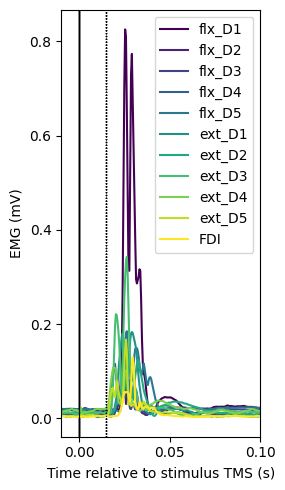

In [99]:
mep_rest = np.load(os.path.join(gl.baseDir, experiment, 'emg', f'subj{sn}', 'emg_raw.tms.rest.npy'))
mep_rect_rest = np.abs(mep_rest)
mep_amp_rest = np.zeros(len(channels_emg))
fig, ax = plt.subplots(figsize=(3, 5))
for ch, channel in enumerate(channels_emg):
    # ax = axs[ch]
    y = mep_rect_rest[:, ch].mean(axis=0)
    mep_amp_rest[ch] = mep_rect_rest[:, ch, int_mep].max(axis=-1).mean()
    ax.plot(tAx, y, color=color[ch], label=channel)
    ax.set_xlim([-.01, .1])
    ax.axvline(0, ls='-', color='k', lw=.8)
    ax.axvline(.015, ls=':', color='k', lw=.8)

ax.set_xlabel('Time relative to stimulus TMS (s)')
ax.set_ylabel('EMG (mV)')
ax.legend()

fig.tight_layout()

plt.show()

/tmp/ipykernel_50837/239029401.py:26: RuntimeWarning: Mean of empty slice.
  y = emg_rect_aligned[(dat_notms.stimFinger==stimF) & (dat_notms.cue==cue), ch].mean(axis=0) #+ ch / 2
/home/UWO/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


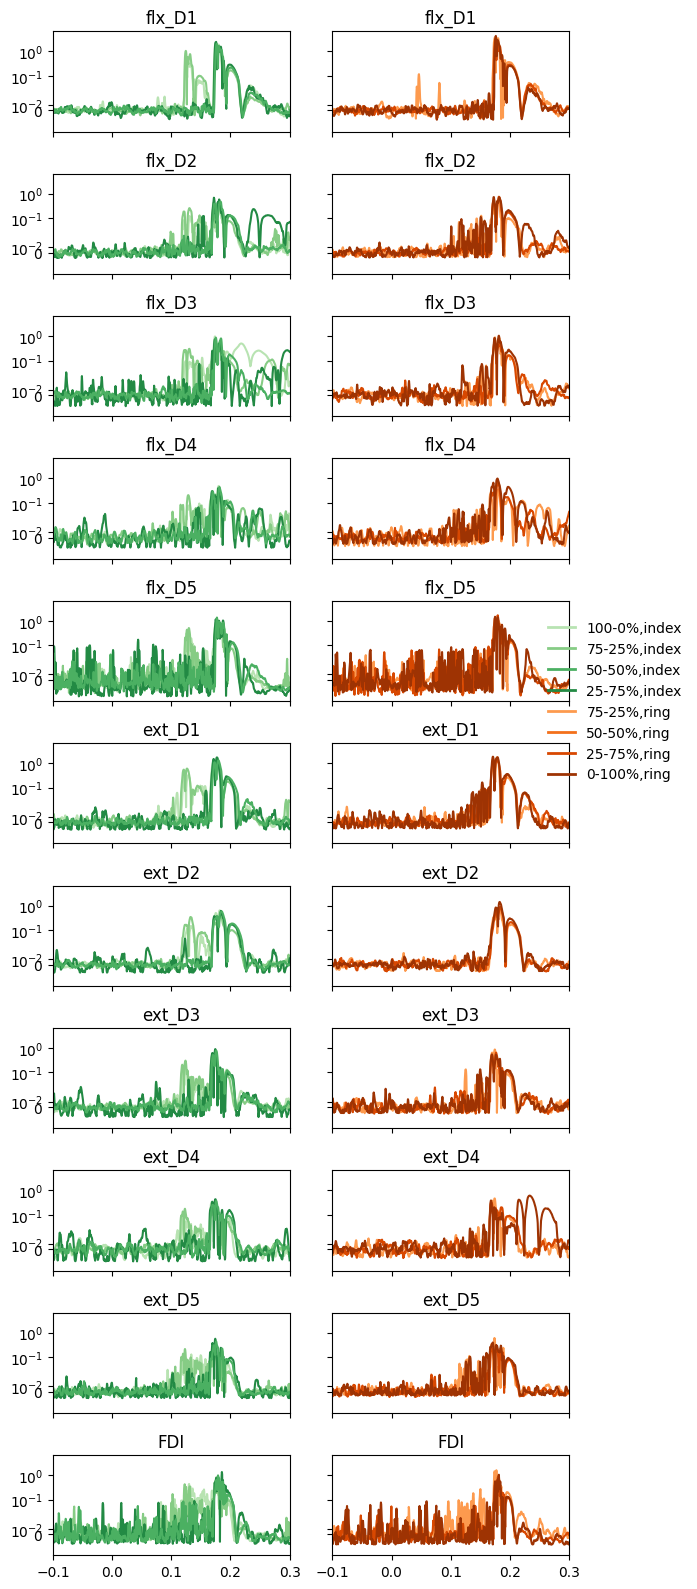

In [114]:
emg = np.load(os.path.join(gl.baseDir, experiment, 'emg', f'subj{sn}', 'emg_raw.behav.task.npy'))
emg_rect = np.abs(emg)
dat_notms = dat[(dat['TrigPlan']==0) & (dat['TrigExec']==1) & (dat['TrigBaseline']==0) & (dat_tms['BN'].isin([5, ]))]
emg_rect = emg_rect[(dat['TrigPlan']==0) & (dat['TrigExec']==1) & (dat['TrigBaseline']==0) & (dat_tms['BN'].isin([5, ]))]

xCentre = (((dat_notms['planTime'] + 50) / 1000).to_numpy() * 2148).astype(int)

emg_rect_aligned = np.array([emg_rect[i, :, xCentre[i] - 2148:xCentre[i] + int(2148 * 1)] for i in range(emg_rect.shape[0])])

tAx = np.linspace(-1, 1, emg_rect_aligned.shape[-1])
int_llr = (tAx > .05) & (tAx <.1)
int_bs = (tAx > -.1) & (tAx <0)

bs = emg_rect_aligned[..., int_bs].mean(axis=-1, keepdims=True)
emg_rect_aligned = emg_rect_aligned - bs

llr = np.zeros((len(channels_emg), 2))

fig, axs = plt.subplots(len(channels_emg), 2, sharex=True, sharey=True, figsize=(6, 16))
for ch, channel in enumerate(channels_emg):
    for sf, stimF in enumerate(dat_notms.stimFinger.unique()):
        llr[ch, sf] = emg_rect_aligned[dat_notms.stimFinger==stimF, ch][..., int_llr].mean(axis=(0, 1)) # store llr amplitude for later
        ax = axs[ch, sf]
        for c, cue in enumerate(dat_notms.cue.unique()):
            if f'{cue},{stimF}' not in ['0-100%,index', '100-0%,ring']:
                y = emg_rect_aligned[(dat_notms.stimFinger==stimF) & (dat_notms.cue==cue), ch].mean(axis=0) #+ ch / 2
                ax.plot(tAx, y, color=gl.colour_mapping[f'{cue},{stimF}'], label=f'{cue},{stimF}')
                ax.set_xlim([-.1, .3])
                ax.set_title(channel)
                ax.set_yscale('symlog', linthresh=.05)
                # if c==0:
                #     ax.text(.01, .25 + ch / 2, channel)

# Create legend entries as colored lines (matching plotted lines)
legend_elements = []
for k,v in gl.colour_mapping.items():
    if 'ring' in k or 'index' in k:
        legend_elements.append(Line2D([0], [0], color=v, lw=2, label=k))

# Add the legend to the figure, outside the right edge
fig.legend(handles=legend_elements,
           loc='lower left',
           bbox_to_anchor=(.9, .5),
           frameon=False)
fig.tight_layout()

plt.show()


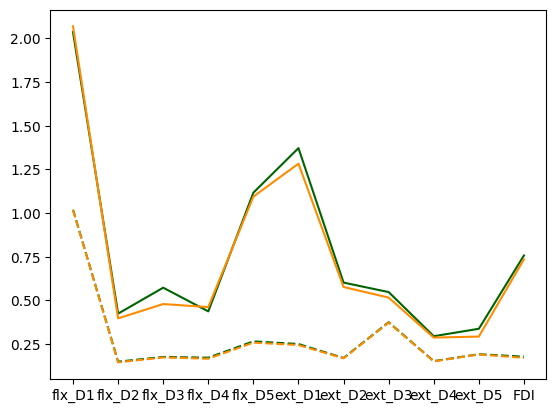

In [91]:
additive_amp = llr + mep_amp_rest[:, None]
fig, ax = plt.subplots()

ax.plot(channels_emg, mep_amp[:, 0], color='darkgreen', label='Index - observed')
ax.plot(channels_emg, mep_amp[:, 1], color='darkorange', label='Ring - observed')
ax.plot(channels_emg, additive_amp[:, 0], color='darkgreen', label='Index - additive', ls='--')
ax.plot(channels_emg, additive_amp[:, 1], color='darkorange', label='Ring - additive', ls='--')

plt.show()